In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./data/final_dataset.csv")

In [3]:
df

,utt_id,maya,spk_id,path
0,spk_001_utt_0001,baach,spk_001,audios/spk_001_utt_0001.wav
1,spk_001_utt_0002,chiich,spk_001,audios/spk_001_utt_0002.wav
2,spk_001_utt_0003,ch'íich',spk_001,audios/spk_001_utt_0003.wav
3,spk_001_utt_0004,ja',spk_001,audios/spk_001_utt_0004.wav
4,spk_001_utt_0005,kool,spk_001,audios/spk_001_utt_0005.wav
...,...,...,...,...
2530,spk_032_utt_0223,jumpuul osea ma jumpuuli cada administración p...,spk_032,audios/spk_032_utt_0223.wav
2531,spk_032_utt_0224,como to'on láaj explicado to'on beeta'an to'on...,spk_032,audios/spk_032_utt_0224.wav
2532,spk_032_utt_0225,le ku xkáakpachtiko'obe ma tu pak'o'obi ma tu ...,spk_032,audios/spk_032_utt_0225.wav
2533,spk_032_utt_0226,teen xan man ti'ob weye camionadasil arroz kin...,spk_032,audios/spk_032_utt_0226.wav


In [4]:
import numpy as np
from IPython.display import Audio
import librosa

def print_audio_by_id(id: int):
    row  = df.iloc[id]
    audio_path = "./" + row["path"]
    audio, sr = librosa.load(audio_path, sr=16000)
    print(row["maya"])
    return Audio(audio, rate=sr)

In [5]:
import soundfile as sf
from datetime import timedelta
from tqdm import tqdm

def _dur(path):
    info = sf.info(path)
    return info.frames / info.samplerate

durations = [_dur("./" + p) for p in tqdm(df["path"])]
df["duration_s"] = durations

total_s = float(df["duration_s"].sum())
print(f"Utterances: {len(df)}")
print(f"Duración total: {timedelta(seconds=int(total_s))} ({total_s:.1f} s)")
print(f"Media: {total_s/len(df):.2f} s  |  Min: {df['duration_s'].min():.2f} s  |  Max: {df['duration_s'].max():.2f} s")

100%|██████████| 2535/2535 [00:00<00:00, 3471.13it/s]

Utterances: 2535
Duración total: 4:21:52 (15712.4 s)
Media: 6.20 s  |  Min: 0.61 s  |  Max: 15.00 s


In [6]:
by_spk = df.groupby("spk_id")["duration_s"].agg(["count", "sum", "mean"])
by_spk["sum_hms"] = by_spk["sum"].apply(lambda s: str(timedelta(seconds=int(s))))
by_spk = by_spk.reset_index()
by_spk

,spk_id,count,sum,mean,sum_hms
0,spk_001,392,937.637000,2.391931,0:15:37
1,spk_002,155,302.960000,1.954581,0:05:02
2,spk_003,28,41.400000,1.478571,0:00:41
3,spk_004,28,43.221000,1.543607,0:00:43
4,spk_005,15,19.450000,1.296667,0:00:19
5,spk_006,334,862.279000,2.581674,0:14:22
6,spk_007,28,39.789000,1.421036,0:00:39
7,spk_008,29,112.500000,3.879310,0:01:52
8,spk_009,96,294.751000,3.070323,0:04:54
9,spk_010,59,171.901000,2.913576,0:02:51


In [7]:
total_s = by_spk["sum"].sum()
total_duration = timedelta(seconds=int(total_s))

str(total_duration) + " hms"

'4:21:52 hms'

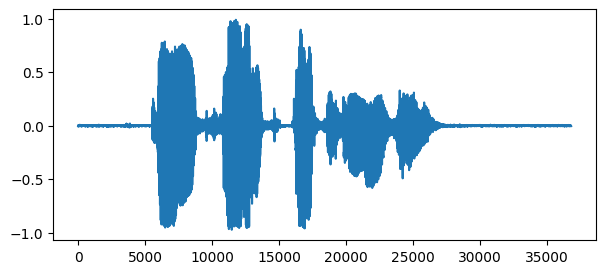

kin ts'áik tech meyaj


In [8]:
import matplotlib.pyplot as plt
import librosa
import numpy as np

# choose random int
i = np.random.randint(0, len(df))

utt = df.iloc[i]

audio, sr = librosa.load("./" + utt["path"], sr=16000)

plt.figure(figsize=(7, 3))
plt.plot(audio)
plt.show()


print(utt["maya"])
Audio("./" + utt["path"], rate=16000)

In [9]:
df_spk = pd.read_csv("./data/spk_metadata.csv")
sex_map = dict(zip(df_spk['spk_id'], df_spk[' sexo']))
sex_map

{'spk_001': 'mujer',
 'spk_002': 'hombre',
 'spk_003': 'hombre',
 'spk_004': 'mujer',
 'spk_005': 'hombre',
 'spk_006': 'mujer',
 'spk_007': 'mujer',
 'spk_008': 'hombre',
 'spk_009': 'hombre',
 'spk_010': 'hombre',
 'spk_011': 'mujer',
 'spk_012': 'mujer',
 'spk_013': 'hombre',
 'spk_014': 'mujer',
 'spk_015': 'mujer',
 'spk_016': 'hombre',
 'spk_017': 'hombre',
 'spk_018': 'hombre',
 'spk_019': 'hombre',
 'spk_020': 'mujer',
 'spk_021': 'hombre',
 'spk_022': 'hombre',
 'spk_023': 'hombre',
 'spk_024': 'mujer',
 'spk_025': 'hombre',
 'spk_026': 'hombre',
 'spk_027': 'hombre',
 'spk_028': 'hombre',
 'spk_029': 'mujer',
 'spk_030': 'hombre',
 'spk_031': 'mujer',
 'spk_032': 'hombre'}

<>:97: SyntaxWarning: invalid escape sequence '\%'
<>:97: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_24529/1595577294.py:97: SyntaxWarning: invalid escape sequence '\%'
  ax2.text(0.5, 0.95, r'$\sum$ = ' + f'{total_mujer_min:.1f} min ({porcentaje_mujer:.1f}$\%$)',
/tmp/ipykernel_24529/1595577294.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(ax3.get_yticklabels(), size=13)


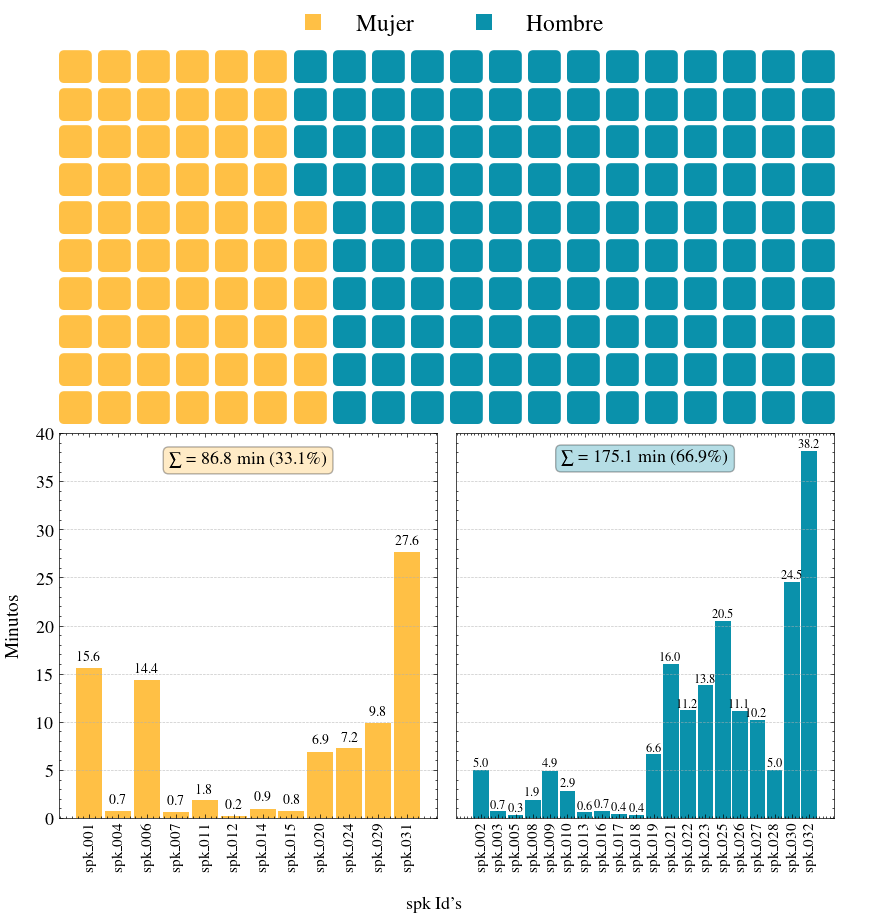

In [10]:
from pywaffle import Waffle
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

female_color = "#FFC045"
male_color = "#0A91AB"

# Primero, calculamos los totales por género
total_mujer = by_spk[by_spk['spk_id'].map(sex_map) == 'mujer']['sum'].sum()
total_hombre = by_spk[by_spk['spk_id'].map(sex_map) == 'hombre']['sum'].sum()

# Convertir a minutos
total_mujer_min = total_mujer / 60
total_hombre_min = total_hombre / 60

# Filtrar por género
df_mujeres = by_spk[by_spk['spk_id'].map(sex_map) == 'mujer']
df_hombres = by_spk[by_spk['spk_id'].map(sex_map) == 'hombre']

total_general = total_mujer_min + total_hombre_min
porcentaje_mujer = (total_mujer_min / total_general) * 100
porcentaje_hombre = (total_hombre_min / total_general) * 100

# Aplicar el estilo para toda la figura
fig = plt.figure(figsize=(10, 10))
with plt.style.context(['science', 'ieee']):
    # Crear figura con GridSpec
    # Ajustar GridSpec para que el waffle ocupe más espacio vertical
    gs = fig.add_gridspec(3, 2, hspace=0.05, wspace=0.05, height_ratios=[2, 1, 1])
    
    # Gráfico 1: Proporción general (arriba, ocupa 2 columnas) - Waffle SIN LEYENDA
    ax1 = fig.add_subplot(gs[0, :])
    with plt.rc_context({'text.usetex': False}):
        Waffle.make_waffle(
            ax=ax1,
            rows=10,
            columns=20,
            values={'Mujer': total_mujer_min, 'Hombre': total_hombre_min},
            colors=[female_color, male_color],
            icons='square',
            icon_size=27,
            icon_legend=False,
        )

    #fig.suptitle('Composición del corpus por género y hablante', 
    #         fontsize=20, 
    #         y=0.96,
    #         fontweight='bold')
    
    if ax1.get_legend():
        ax1.get_legend().remove()

    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], marker='s', color='w', 
            markerfacecolor=female_color, markersize=12,
            label='Mujer', markeredgewidth=0),
        Line2D([0], [0], marker='s', color='w', 
            markerfacecolor=male_color, markersize=12,
            label='Hombre', markeredgewidth=0)
    ]

    ax1.legend(handles=legend_elements, 
            loc='upper center',
            bbox_to_anchor=(0.5, 1.15),
            ncol=2,
            frameon=False,
            fontsize=17,
            columnspacing=2
        )
    
    # Gráfico 2: Barras Mujeres (abajo izquierda)
    ax2 = fig.add_subplot(gs[1:, 0])
    
    bars_mujeres = df_mujeres['sum'].values / 60
    spk_mujeres = df_mujeres['spk_id'].values
    #colores_mujeres = [plt.cm.Greens(i) for i in np.linspace(0.5, 0.9, len(spk_mujeres))]
    
    ax2.bar(range(len(spk_mujeres)), bars_mujeres, width=0.9, color=female_color)
    ax2.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)
    ax2.set_xticks(range(len(spk_mujeres)))
    ax2.set_xticklabels(spk_mujeres, rotation=90, size=11, ha='center')
    ax2.set_ylim(0, 40)
    ax2.set_yticks(np.arange(0, 45, 5))
    ax2.set_yticklabels(ax2.get_yticklabels(), size=13)
    ax2.set_ylabel("Minutos", size=14, labelpad=10)
    #ax2.set_xlabel("Hablante ID", size=14, labelpad=10)
    
    # Texto encima de las barras
    for i, (spk, val) in enumerate(zip(spk_mujeres, bars_mujeres)):
        ax2.text(i, val + 0.5, f"{val:.1f}", 
                ha='center', va='bottom', fontsize=10)
    
    # Texto con suma total usando LaTeX
    ax2.text(0.5, 0.95, r'$\sum$ = ' + f'{total_mujer_min:.1f} min ({porcentaje_mujer:.1f}$\%$)', 
            transform=ax2.transAxes, ha='center', va='top',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=female_color, alpha=0.3))
    
    # Gráfico 3: Barras Hombres (abajo derecha)
    ax3 = fig.add_subplot(gs[1:, 1])
    
    bars_hombres = df_hombres['sum'].values / 60
    spk_hombres = df_hombres['spk_id'].values
    #colores_hombres = [plt.cm.Blues(i) for i in np.linspace(0.5, 0.9, len(spk_hombres))]
    
    ax3.bar(range(len(spk_hombres)), bars_hombres, width=0.9, color=male_color)
    ax3.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)
    ax3.set_xticks(range(len(spk_hombres)))
    ax3.set_xticklabels(spk_hombres, rotation=90, size=11, ha='center')
    ax3.set_ylim(0, 40)
    ax3.set_yticklabels(ax3.get_yticklabels(), size=13)
    ax3.tick_params(left=False, labelleft=False)
    ax3.set_ylabel("")
    
    # Texto encima de las barras
    for i, (spk, val) in enumerate(zip(spk_hombres, bars_hombres)):
        ax3.text(i, val + 0.1, f"{val:.1f}", 
                ha='center', va='bottom', fontsize=9)
    
    # Texto con suma total usando LaTeX
    ax3.text(0.5, 0.955, r'$\sum$ = ' + rf'{total_hombre_min:.1f} min ({porcentaje_hombre:.1f}$\%$)', 
            transform=ax3.transAxes, ha='center', va='top',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=male_color, alpha=0.3))
    
    fig.text(0.5, 0.02, "spk Id's", fontsize=13, ha="center")
    fig.text(0.95, 0.1, " ", fontsize=20)
    plt.savefig("./figures/distribucion_audio_genero.svg", bbox_inches='tight', format='svg')
    #plt.savefig("./figures/distribucion_audio_genero.png", bbox_inches='tight', dpi=300)
    plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\%'
<>:31: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_24529/624994062.py:31: SyntaxWarning: invalid escape sequence '\%'
  ax2.text(0.5, 0.95, r'$\sum$ = ' + f'{total_mujer_min:.1f} min ({porcentaje_mujer:.1f}$\%$ female)',
/tmp/ipykernel_24529/624994062.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(ax3.get_yticklabels(), size=13)


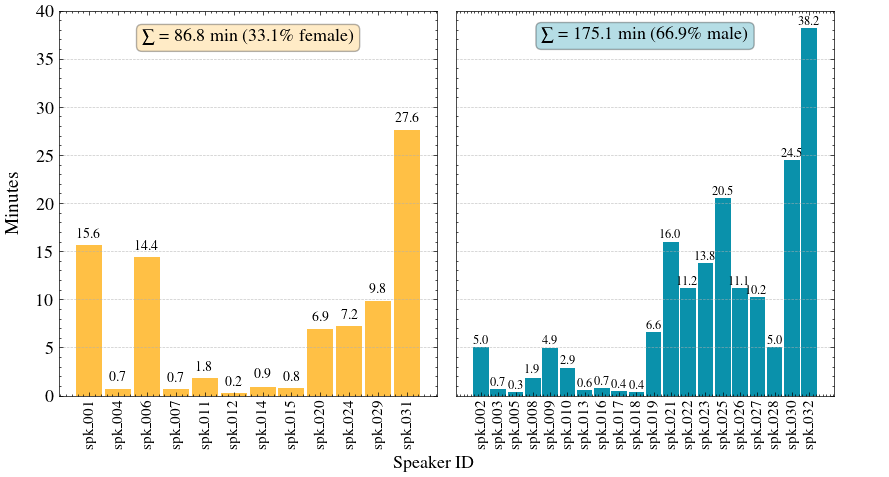

In [12]:
# Aplicar el estilo para toda la figura
fig = plt.figure(figsize=(10, 5))
with plt.style.context(['science', 'ieee']):
    # Crear figura con GridSpec
    # Ajustar GridSpec para que el waffle ocupe más espacio vertical
    gs = fig.add_gridspec(1, 2, hspace=0.05, wspace=0.05)
    
    # Gráfico 2: Barras Mujeres (abajo izquierda)
    ax2 = fig.add_subplot(gs[0:, 0])
    
    bars_mujeres = df_mujeres['sum'].values / 60
    spk_mujeres = df_mujeres['spk_id'].values
    #colores_mujeres = [plt.cm.Greens(i) for i in np.linspace(0.5, 0.9, len(spk_mujeres))]
    
    ax2.bar(range(len(spk_mujeres)), bars_mujeres, width=0.9, color=female_color)
    ax2.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)
    ax2.set_xticks(range(len(spk_mujeres)))
    ax2.set_xticklabels(spk_mujeres, rotation=90, size=11, ha='center')
    ax2.set_ylim(0, 40)
    ax2.set_yticks(np.arange(0, 45, 5))
    ax2.set_yticklabels(ax2.get_yticklabels(), size=13)
    ax2.set_ylabel("Minutes", size=14, labelpad=10)
    #ax2.set_xlabel("Hablante ID", size=14, labelpad=10)
    
    # Texto encima de las barras
    for i, (spk, val) in enumerate(zip(spk_mujeres, bars_mujeres)):
        ax2.text(i, val + 0.5, f"{val:.1f}", 
                ha='center', va='bottom', fontsize=10)
    
    # Texto con suma total usando LaTeX
    ax2.text(0.5, 0.95, r'$\sum$ = ' + f'{total_mujer_min:.1f} min ({porcentaje_mujer:.1f}$\%$ female)', 
            transform=ax2.transAxes, ha='center', va='top',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=female_color, alpha=0.3))
    
    # Gráfico 3: Barras Hombres (abajo derecha)
    ax3 = fig.add_subplot(gs[0:, 1])
    
    bars_hombres = df_hombres['sum'].values / 60
    spk_hombres = df_hombres['spk_id'].values
    #colores_hombres = [plt.cm.Blues(i) for i in np.linspace(0.5, 0.9, len(spk_hombres))]
    
    ax3.bar(range(len(spk_hombres)), bars_hombres, width=0.9, color=male_color)
    ax3.grid(True, axis='y', alpha=0.7, linestyle='--', linewidth=0.5)
    ax3.set_xticks(range(len(spk_hombres)))
    ax3.set_xticklabels(spk_hombres, rotation=90, size=11, ha='center')
    ax3.set_ylim(0, 40)
    ax3.set_yticklabels(ax3.get_yticklabels(), size=13)
    ax3.tick_params(left=False, labelleft=False)
    ax3.set_ylabel("")

    # Texto encima de las barras
    for i, (spk, val) in enumerate(zip(spk_hombres, bars_hombres)):
        ax3.text(i, val + 0.1, f"{val:.1f}", 
                ha='center', va='bottom', fontsize=9)
    
    # Texto con suma total usando LaTeX
    ax3.text(0.5, 0.955, r'$\sum$ = ' + rf'{total_hombre_min:.1f} min ({porcentaje_hombre:.1f}$\%$ male)', 
            transform=ax3.transAxes, ha='center', va='top',
            fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=male_color, alpha=0.3))
    
    fig.text(0.5, -0.035, "Speaker ID", fontsize=13, ha="center")
    fig.text(0.95, 0.1, " ", fontsize=20)
    plt.savefig("./figures/distribucion_audio_genero_paper.pdf", bbox_inches='tight', format='pdf')
    #plt.savefig("./figures/distribucion_audio_genero.png", bbox_inches='tight', dpi=300)
    plt.show()